In [1]:
import warnings
import os
import sys
warnings.filterwarnings("ignore")
username = os.getlogin()
sys.path.append(rf'/home/{username}/data_share_p')

In [2]:
import FactorFramework.FactorFramework as ff
ff.set_gpu_device('cuda:0')

In [3]:
# 写出表达式
# test_exp = 'ts_corr(div(OrderAmtSum_B, OrderVolSum_B), bp1, 30)'
test_exp = 'ts_obnm(ts_hmean(vol_to_last_sv, 5), ts_regbeta(press_imbalance, md_10, 15), 5)'

In [4]:
# 调用ff.backtest进行回测

# fac_exp即为计算用的表达式
# 支持算子和字符串的任意组合

# fac_name是因子名称 
# 为了方便区分不同种类的因子，因子命名需要写为：版本号_具体名称，fac_name中第一个出现的下划线前面的内容会被识别为版本号
# 例如，dev_fac表明计算的因子名称是版本号dev下面的fac因子，Mom1_ret5min是版本号Mom1下的ret5min因子。某个版本号的因子会存放在同一个目录下

# 形如outputXXXX的目录下存放的是因子数据，形如outputXXXX_labelXXXX的目录下存放的是因子在对应的label上的回测结果

# calc_mode是计算模式，'daily'代表按日计算，'cont'代表连续计算，即将跨天的数据直接拼接在一起计算
# intraday_data_only代表是否只使用日内数据
# 对一般的股票因子建议采用calc_mode='daily', intraday_data_only=True

# check_fac_name_duplicate代表是否检测因子名重复问题。如果之前生成并且保存过同名因子，并且开启检测，会对每个因子进行手动弹窗确认是否覆盖
# 如果不开启同名检测，会直接覆盖原有结果
# dev_fac这个名称的因子是留出来debug或者看初步效果使用的临时名称，如果名称为dev_fac，则不受上述逻辑管辖，一定会覆盖上一个dev_fac的结果

# save_fac_data代表是否保存因子的数据。因子数据会占用较大存储空间，一般不建议全部保存
# 因子的回测结果占用空间很小，会默认全部保存
# 可以根据因子的回测结果筛选出最终想要使用的因子，然后再对这些因子使用save_fac_data=True保存数值结果，后续进行模型训练

In [ ]:
ff.fac_backtest(fac_exp=test_exp, fac_name='dev_fac', calc_mode='daily', intraday_data_only=True, check_fac_name_duplicate=False, save_fac_data=False, just_return_backtest_result=False)

In [ ]:
# 调用ff.get_all_backtest_result展示回测结果
# fac_name同上的fac_name
# label_name_list是关心的label列表
# print_tabel和print_figure代表是否打印回测表格/回测图

fac_name: dev_fac
label_name: label4
       period_name   ic  rank_ic  group1  group20  tail50  tail100  head50  head100  nan_proportion  zero_proportion
0  period1         -2.6 -6.6      21.9   -41.4     20.4    21.2    -45.0   -46.4     0.0             0.0            
1  period2         -1.9 -6.3      24.9   -35.4     27.4    24.7    -23.5   -23.2     0.0             0.0            
2  period3         -2.0 -6.0      28.5   -32.7     28.7    29.8    -37.5   -37.7     0.0             0.0            
3  period4         -2.0 -5.9      25.5   -34.2     22.2    25.5    -39.7   -35.7     0.0             0.0            
4  period5         -2.0 -6.0      23.8   -36.5     25.6    26.9    -42.1   -44.5     0.0             0.0            
5  period6         -2.0 -5.9      24.1   -36.8     22.1    23.0    -29.0   -30.0     0.0             0.0            
6  period7         -2.1 -5.8      23.6   -35.4     19.1    21.0    -42.0   -35.4     0.0             0.0            
7  all_period_mean -2.1 -6.

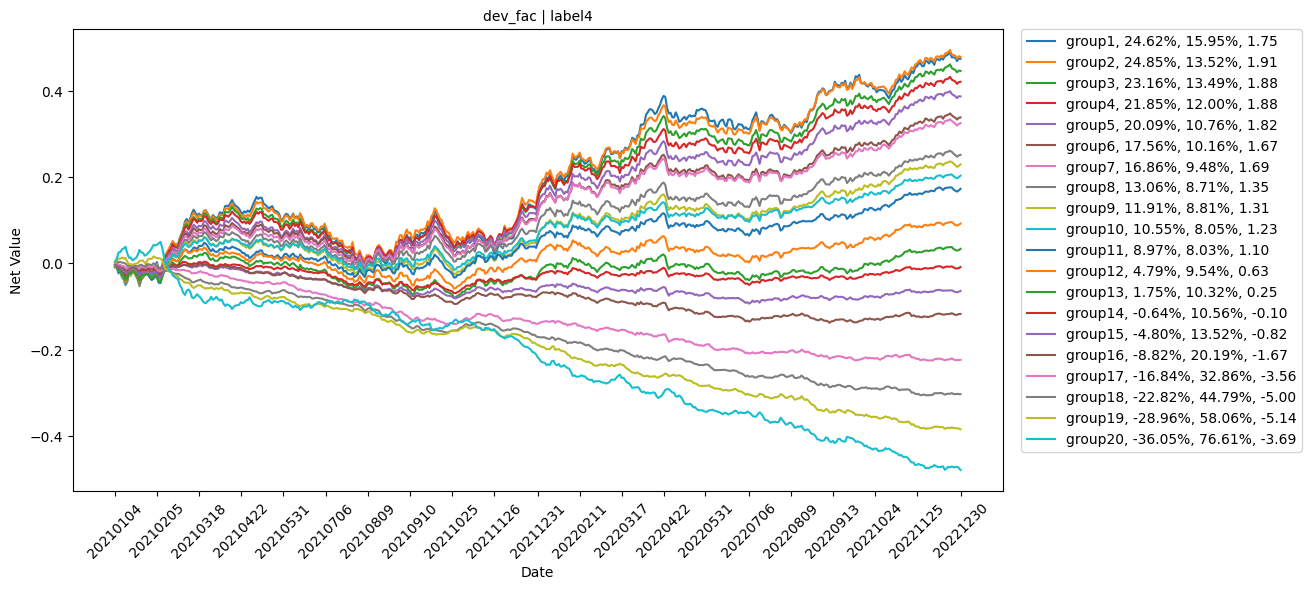

fac_name: dev_fac
label_name: alpha4
       period_name   ic  rank_ic  group1  group20  tail50  tail100  head50  head100  nan_proportion  zero_proportion
0  period1         -1.2  3.5      1.7    -20.6    -4.2    -1.0     -22.8   -20.4     0.0             0.0            
1  period2         -1.0  4.6      4.7    -16.4     3.2     3.3     -5.9    -5.1      0.0             0.0            
2  period3         -0.8  5.5      8.7    -11.8     8.4     9.0     -13.2   -13.6     0.0             0.0            
3  period4         -0.9  5.9      6.3    -15.2     0.9     5.5     -20.5   -15.4     0.0             0.0            
4  period5         -0.8  5.7      6.5    -12.6     6.1     7.4     -17.2   -18.9     0.0             0.0            
5  period6         -0.9  6.2      6.5    -15.1     4.5     5.4     -6.0    -4.3      0.0             0.0            
6  period7         -0.9  6.8      5.7    -12.1     1.6     2.9     -17.3   -9.6      0.0             0.0            
7  all_period_mean -0.9  5.

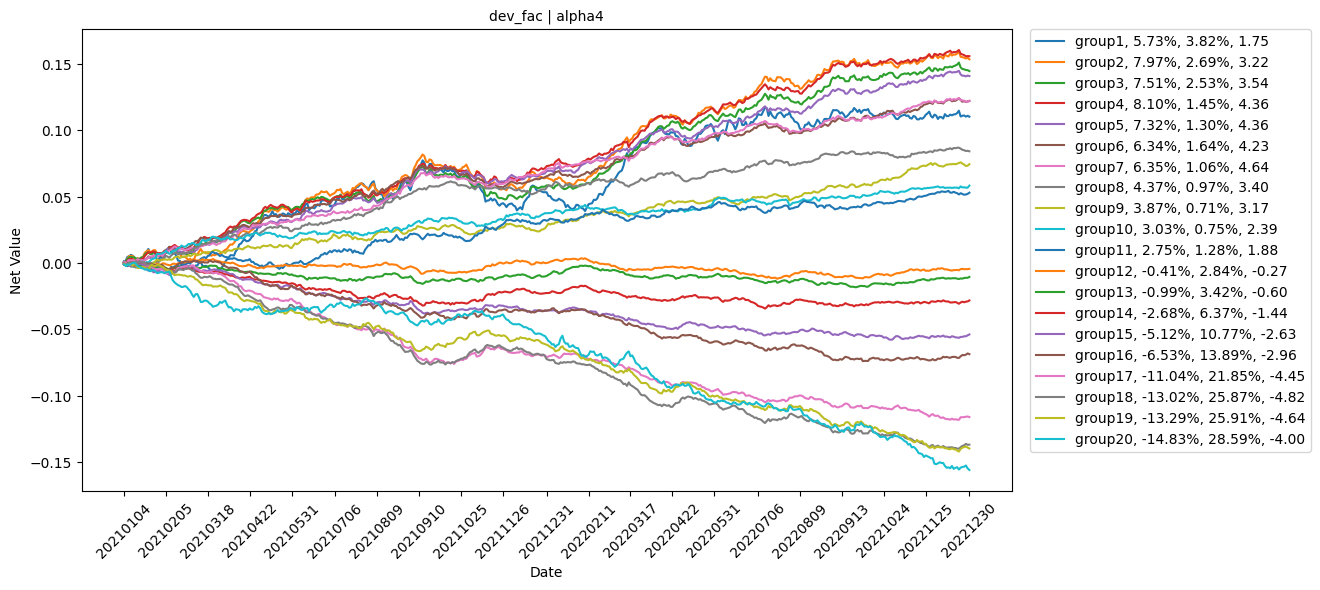

fac_name: dev_fac
label_name: label5
       period_name   ic  rank_ic  group1  group20  tail50  tail100  head50  head100  nan_proportion  zero_proportion
0  period1         -2.7 -4.6      31.1    1.5      13.4    19.2    -191.7  -193.4    0.0             0.0            
1  all_period_mean -2.7 -4.6      31.1    1.5      13.4    19.2    -191.7  -193.4    0.0             0.0            


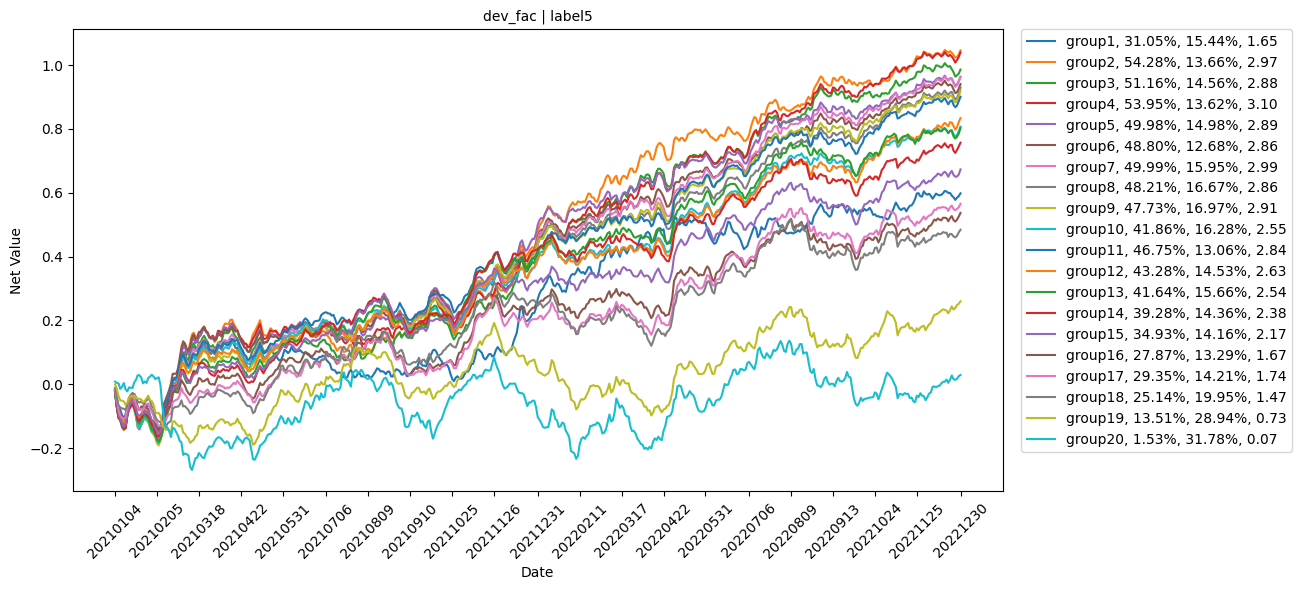

In [ ]:
ff.get_all_backtest_result(fac_name='dev_fac', label_name_list=['label4', 'alpha4', 'label5'], print_tabel=True, print_figure=True)